# Paper figures (draft): init_scale × sparsity × task similarity

This notebook drafts final paper-style figures from the existing simulation outputs.

**Default architecture:** task-routed two-module RNN (25 hidden per module, `nb_steps=2`).

**Minimal comparison grid (task-routed):**
- **sparsity** ∈ {`no_comms`, `0.5`, `1.0`}
- **task similarity** ∈ {`same`, `near`, `far`}
- **init_scale** ∈ {`0.001`,`0.01`, `0.1`, `1.0`, `2`}

**Ablations:** shared routing (matched settings) treated as ablation (optionally add `single_module`).

## Figures in this draft
- Transfer/interference (`error_diff`) + phase accuracies
- Principal angles (A vs B subspaces)
- PC count across phases (`n_pcs_99`, 99% variance)
- Curated 2D PCA geometry snapshots


In [31]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}

PHASE_ORDER = ["post_A", "post_B", "post_A2"]

# We keep the same global ordering conventions as the existing notebooks.
INIT_SCALE_ORDER = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 2]
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]

# Minimal paper grid
PAPER_INIT_SCALES = [0.001, 0.01, 0.1, 1.0, 2]
PAPER_SPARSITIES = ["no_comms", "0.5", "1.0"]

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.paper_single_baseline import (
    ROUTING_HUE_ORDER,
    ROUTING_PALETTE,
    broadcast_baseline_sparsity,
    select_single_baseline_df,
)
from a1b2.analysis.transfer_interference import prepare_pca_shared_three_phase
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2, get_axis_limits

sim_folder = (project_root / "data" / "simulations")
config_path = (project_root / "a1b2" / "models" / "experiments.json")
settings = json.loads(config_path.read_text())

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Config:", config_path)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Config: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/experiments.json


In [32]:
# 2) Select runs for the paper grid (task-routed default + shared ablation)

TARGET_ARCH = "two_module_rnn"
TARGET_DIM_HIDDEN = 6
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def select_conditions(input_routing: str):
    conds = []
    for c in settings["conditions"]:
        if c.get("arch") != TARGET_ARCH:
            continue
        if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
            continue
        if c.get("nb_steps", 1) != TARGET_NB_STEPS:
            continue
        if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
            continue
        if c.get("common_input", False) is not TARGET_COMMON_INPUT:
            continue
        if c.get("input_routing", "shared") != input_routing:
            continue

        sp_label = sparsity_label_from_condition(c)
        init_scale = init_scale_from_condition(c)

        if sp_label not in PAPER_SPARSITIES:
            continue
        if init_scale not in PAPER_INIT_SCALES:
            continue

        run_id = build_run_id(c)
        path = sim_folder / run_id
        conds.append(
            {
                **c,
                "run_id": run_id,
                "path": str(path),
                "path_exists": path.exists(),
                "sparsity_label": sp_label,
                "init_scale": init_scale,
            }
        )

    df = pd.DataFrame(conds)
    if df.empty:
        return df

    df["sparsity_label"] = pd.Categorical(df["sparsity_label"], categories=SPARSITY_ORDER, ordered=True)
    df = df.sort_values(["sparsity_label", "init_scale", "name"]).reset_index(drop=True)
    return df


task_df = select_conditions("task_routed")
shared_df = select_conditions("shared")

print("Task-routed selected:", len(task_df), "valid:", int(task_df["path_exists"].sum()))
print("Shared selected:", len(shared_df), "valid:", int(shared_df["path_exists"].sum()))

display(task_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])
display(shared_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])

single_df = select_single_baseline_df(
    settings,
    sim_folder,
    two_module_dim_hidden=TARGET_DIM_HIDDEN,
    paper_sparsities=PAPER_SPARSITIES,
    paper_init_scales=PAPER_INIT_SCALES,
    sparsity_order=SPARSITY_ORDER,
    build_run_id=build_run_id,
    sparsity_label_from_condition=sparsity_label_from_condition,
    init_scale_from_condition=init_scale_from_condition,
    target_nb_steps=TARGET_NB_STEPS,
    target_common_readout=TARGET_COMMON_READOUT,
    target_common_input=TARGET_COMMON_INPUT,
)

print(
    "Single-module baseline:",
    len(single_df),
    "valid:",
    int(single_df["path_exists"].sum()) if len(single_df) else 0,
)
if len(single_df):
    display(single_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])


Task-routed selected: 30 valid: 11
Shared selected: 30 valid: 11


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.001,no_comms,True
1,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.001,no_comms,False
2,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.010,no_comms,True
3,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.010,no_comms,False
4,two_module_rnn_6_task_routed_no_comms_nb2_init0.1,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.100,no_comms,True
5,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,0.100,no_comms,False
6,two_module_rnn_6_task_routed_no_comms_nb2,two_module_rnn_6_task_routed_no_comms_nb2_nb2_...,1.000,no_comms,True
7,two_module_rnn_6_task_routed_no_comms_nb2_inpu...,two_module_rnn_6_task_routed_no_comms_nb2_inpu...,1.000,no_comms,False
8,two_module_rnn_6_task_routed_no_comms_nb2_init2,two_module_rnn_6_task_routed_no_comms_nb2_init...,2.000,no_comms,True
9,two_module_rnn_6_task_routed_no_comms_nb2_init...,two_module_rnn_6_task_routed_no_comms_nb2_init...,2.000,no_comms,False


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_6_no_comms_nb2_init0.001,two_module_rnn_6_no_comms_nb2_init0.001_nb2_sh...,0.001,no_comms,True
1,two_module_rnn_6_no_comms_nb2_init0.001_input_...,two_module_rnn_6_no_comms_nb2_init0.001_input_...,0.001,no_comms,False
2,two_module_rnn_6_no_comms_nb2_init0.01,two_module_rnn_6_no_comms_nb2_init0.01_nb2_sha...,0.010,no_comms,True
3,two_module_rnn_6_no_comms_nb2_init0.01_input_only,two_module_rnn_6_no_comms_nb2_init0.01_input_o...,0.010,no_comms,False
4,two_module_rnn_6_no_comms_nb2_init0.1,two_module_rnn_6_no_comms_nb2_init0.1_nb2_shar...,0.100,no_comms,True
5,two_module_rnn_6_no_comms_nb2_init0.1_input_only,two_module_rnn_6_no_comms_nb2_init0.1_input_on...,0.100,no_comms,False
6,two_module_rnn_6_no_comms_nb2,two_module_rnn_6_no_comms_nb2_nb2_shared_sp0_s...,1.000,no_comms,True
7,two_module_rnn_6_no_comms_nb2_input_only,two_module_rnn_6_no_comms_nb2_input_only_nb2_s...,1.000,no_comms,False
8,two_module_rnn_6_no_comms_nb2_init2,two_module_rnn_6_no_comms_nb2_init2_nb2_shared...,2.000,no_comms,True
9,two_module_rnn_6_no_comms_nb2_init2_input_only,two_module_rnn_6_no_comms_nb2_init2_input_only...,2.000,no_comms,False


Single-module baseline: 5 valid: 3


,name,run_id,init_scale,sparsity_label,path_exists
0,single_module_rnn_12_nb2_init0.001,single_module_rnn_12_nb2_init0.001_nb2_shared_...,0.001,1.0,True
1,single_module_rnn_12_nb2_init0.01,single_module_rnn_12_nb2_init0.01_nb2_shared_s...,0.010,1.0,False
2,single_module_rnn_12_nb2_init0.1,single_module_rnn_12_nb2_init0.1_nb2_shared_sp...,0.100,1.0,False
3,single_module_rnn_12_nb2,single_module_rnn_12_nb2_nb2_shared_sp1_sep_cr...,1.000,1.0,True
4,single_module_rnn_12_nb2_init2,single_module_rnn_12_nb2_init2_nb2_shared_sp1_...,2.000,1.0,True


In [33]:
# 3) Load ANN data + build participant-level dataframes (transfer, phase accuracies, rep metrics, angles)

from collections import defaultdict


def load_all_ann_data(df_runs: pd.DataFrame):
    out = {}
    for _, row in df_runs[df_runs["path_exists"]].iterrows():
        run_id = row["run_id"]
        path = Path(row["path"])
        ann_data = ann.load_ann_data(path)
        out[run_id] = {
            "data": ann_data,
            "init_scale": float(row["init_scale"]),
            "sparsity_label": str(row["sparsity_label"]),
        }
    return out


def compute_metrics(all_ann_data: dict):
    transfer_records = []
    accuracy_records = []
    rep_records = []
    angles_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]

        # principal angles (A vs B)
        angles_df = ann.get_principal_angles(ann_data)
        angles_df = angles_df.copy()
        angles_df["run_id"] = run_id
        angles_df["init_scale"] = init_scale
        angles_df["sparsity_label"] = sp_label
        angles_records.append(angles_df)

        # participant-level metrics
        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))

                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                # Transfer (error_diff): init_B - final_A1
                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        final_A1 = float(np.mean(A1_acc[-6:]))
                        init_B = float(np.mean(B_acc[:6]))
                        transfer_records.append(
                            {
                                "run_id": run_id,
                                "init_scale": init_scale,
                                "sparsity_label": sp_label,
                                "condition": cond_name,
                                "participant": pid,
                                "error_diff": init_B - final_A1,
                            }
                        )

                # Phase accuracies
                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = PHASE_ORDER[ph]
                    accuracy_records.append(
                        {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                        }
                    )

                # Representation metrics (combined/core/comms) per phase
                for phase_idx, phase_name in enumerate(PHASE_ORDER):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for path in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(
                            hids, variance_thresholds=(0.95, 0.99), top_k=2
                        )
                        row = {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "pathway": path,
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            row[f"n_pcs_{int(thr*100)}"] = int(n)
                        rep_records.append(row)

    transfer_df = pd.DataFrame(transfer_records)
    acc_df = pd.DataFrame(accuracy_records)
    rep_df = pd.DataFrame(rep_records)
    angles_all = pd.concat(angles_records, ignore_index=True) if angles_records else pd.DataFrame()

    return transfer_df, acc_df, rep_df, angles_all


all_task = load_all_ann_data(task_df)
all_shared = load_all_ann_data(shared_df)

transfer_task, acc_task, rep_task, angles_task = compute_metrics(all_task)
transfer_shared, acc_shared, rep_shared, angles_shared = compute_metrics(all_shared)
all_single = load_all_ann_data(single_df) if len(single_df) else {}
transfer_single, acc_single, rep_single, angles_single = compute_metrics(all_single)

print("task: transfer", transfer_task.shape, "acc", acc_task.shape, "rep", rep_task.shape, "angles", angles_task.shape)
print("shared: transfer", transfer_shared.shape, "acc", acc_shared.shape, "rep", rep_shared.shape, "angles", angles_shared.shape)
print(
    "single: transfer",
    transfer_single.shape,
    "acc",
    acc_single.shape,
    "rep",
    rep_single.shape,
    "angles",
    angles_single.shape,
)


task: transfer (2847, 6) acc (8541, 7) rep (8541, 10) angles (2847, 6)
shared: transfer (2815, 6) acc (8445, 7) rep (8445, 10) angles (2815, 6)
single: transfer (121, 6) acc (363, 7) rep (363, 10) angles (121, 6)


## Figure 1 (draft): Paper-faithful transfer and phase accuracy (task-routed)

Goal: show how **task similarity × sparsity × init_scale** shapes behavior. We plot:
- `error_diff` (paper-faithful transfer)
- `mean_accuracy` in `post_B` and `post_A2`

Layout: rows = sparsity, columns = init_scale, hue = similarity.

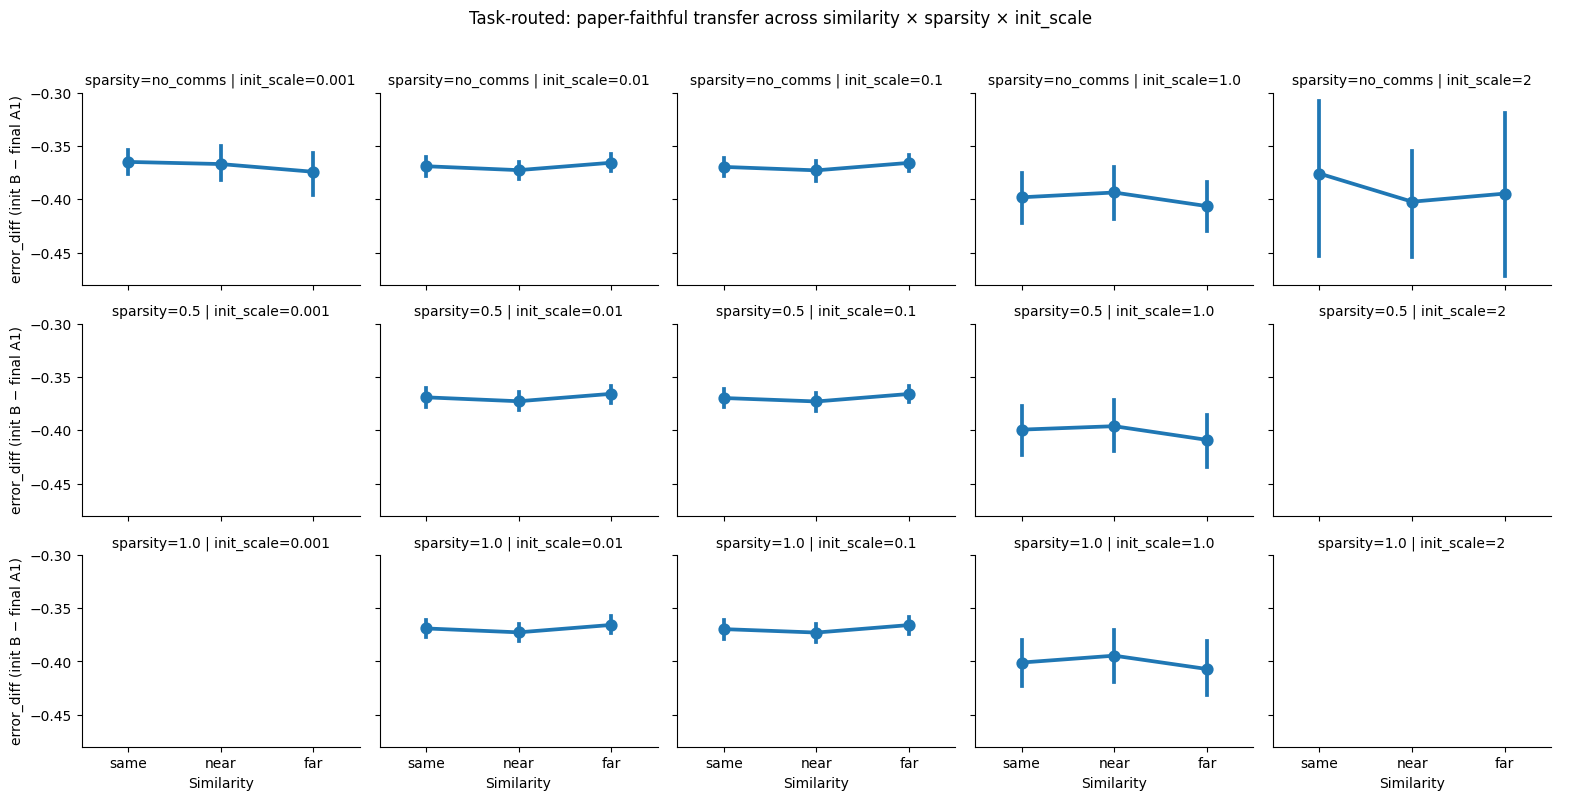

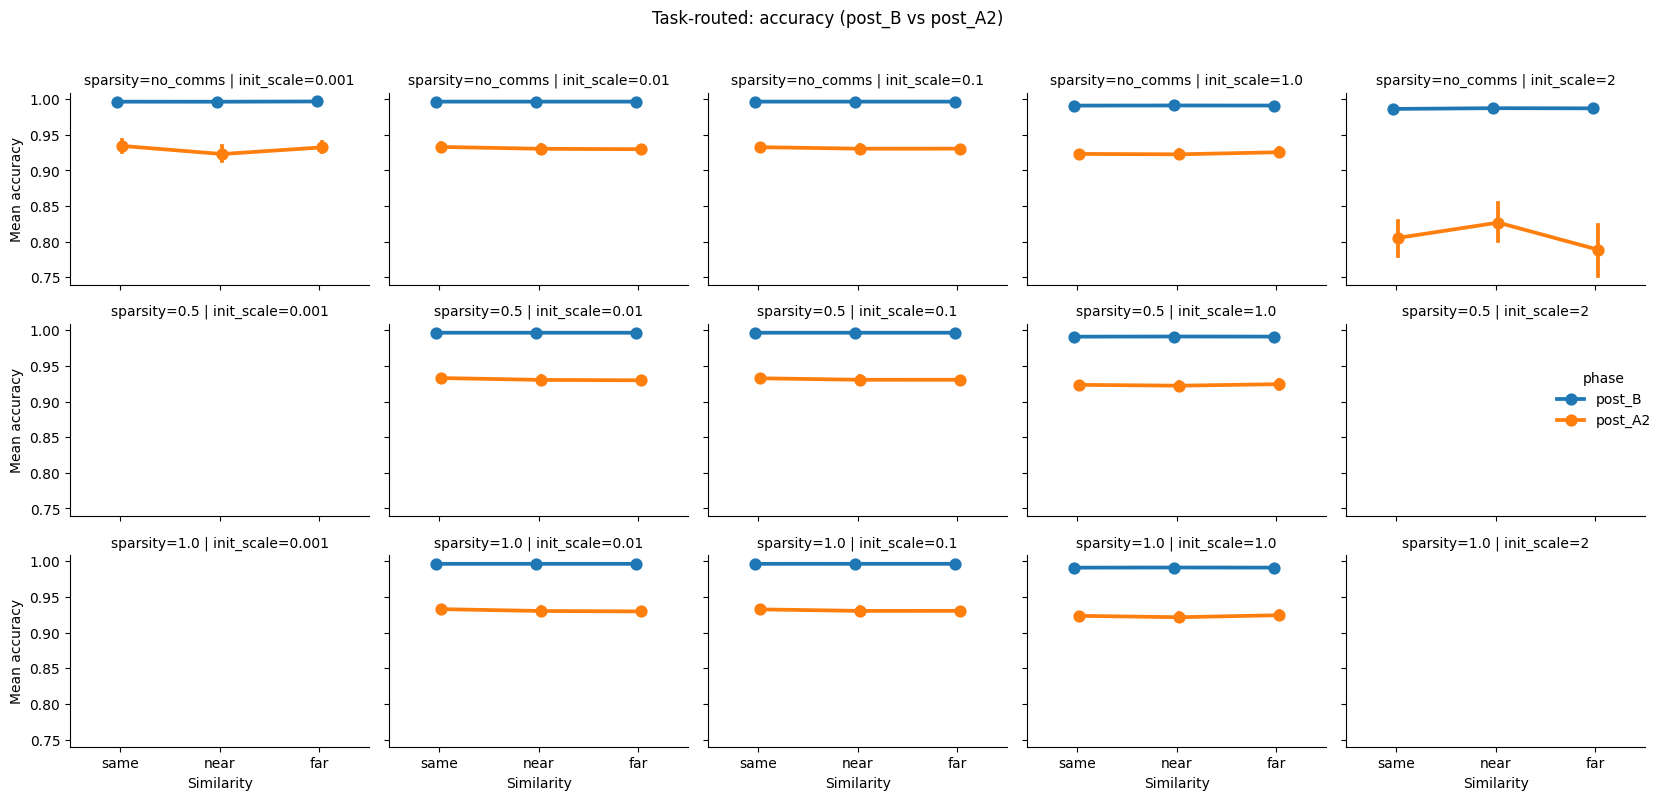

In [34]:
def _facet_orders():
    init_order = [s for s in PAPER_INIT_SCALES if s in INIT_SCALE_ORDER]
    sp_order = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
    return init_order, sp_order


init_order, sp_order = _facet_orders()

# Transfer/interference
if not transfer_task.empty:
    tr = transfer_task.copy()
    tr["init_scale"] = tr["init_scale"].astype(float)
    g = sns.catplot(
        data=tr,
        x="condition",
        y="error_diff",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "error_diff (init B − final A1)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: paper-faithful transfer across similarity × sparsity × init_scale", y=1.02)
    plt.tight_layout()
    plt.show()

# Accuracy in key phases
if not acc_task.empty:
    sub = acc_task[acc_task["phase"].isin(["post_B", "post_A2"])].copy()
    sub["init_scale"] = sub["init_scale"].astype(float)
    g = sns.catplot(
        data=sub,
        x="condition",
        y="mean_accuracy",
        hue="phase",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=["post_B", "post_A2"],
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "Mean accuracy")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: accuracy (post_B vs post_A2)", y=1.02)
    plt.tight_layout()
    plt.show()

## Figure 2 (draft): Principal angles between A and B subspaces (task-routed)

Goal: link behavior to representational separation.

Layout: rows = sparsity, columns = init_scale, hue = similarity (same/near/far).

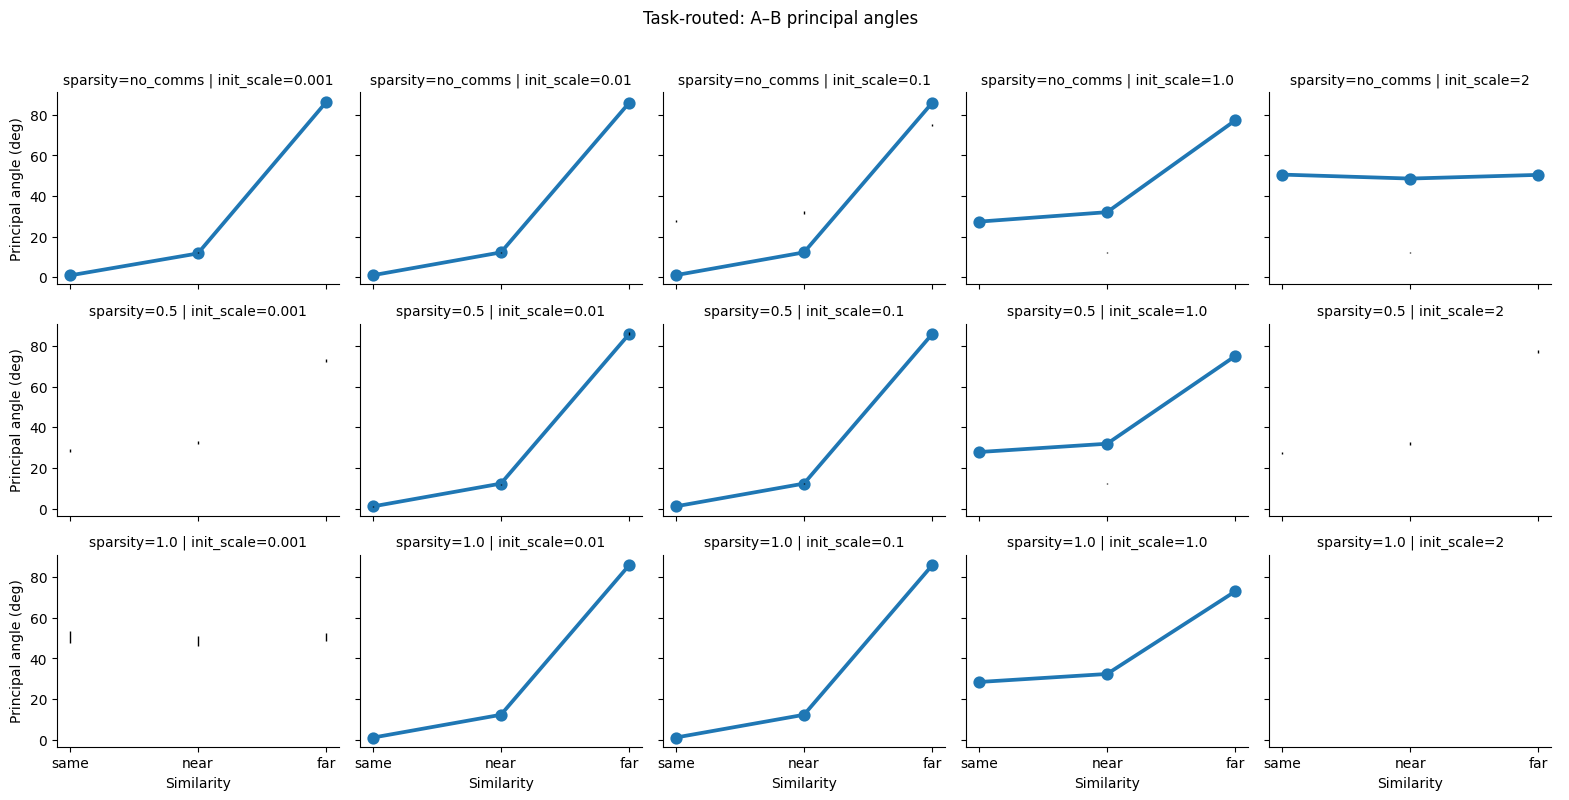

In [35]:
if not angles_task.empty:
    ang = angles_task.copy()
    ang["init_scale"] = ang["init_scale"].astype(float)

    # aggregate to mean ± sem for cleaner paper plot
    ang_agg = (
        ang.groupby(["sparsity_label", "init_scale", "condition"], as_index=False)["principal_angle_between"]
        .agg(["mean", "sem"])
        .reset_index()
        .rename(columns={"mean": "angle_mean", "sem": "angle_sem"})
    )

    g = sns.catplot(
        data=ang_agg,
        x="condition",
        y="angle_mean",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.6,
        aspect=1.2,
    )

    # add SEM bars manually
    for ax, (_, subdf) in zip(g.axes.flat, ang_agg.groupby(["sparsity_label", "init_scale"], sort=False)):
        # seaborn positions: 0,1,2 in SIMILARITY_ORDER
        x = np.arange(len(SIMILARITY_ORDER))
        subdf = subdf.set_index("condition").reindex(SIMILARITY_ORDER)
        ax.errorbar(x, subdf["angle_mean"].values, yerr=subdf["angle_sem"].values, fmt="none", c="black", lw=1)

    g.set_axis_labels("Similarity", "Principal angle (deg)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Task-routed: A–B principal angles", y=1.02)
    plt.tight_layout()
    plt.show()

## Figure 3 (draft): PC count by task similarity and phase (task-routed)

Goal: show **99% variance** PC counts across continual-learning phases.

- **x-axis:** task similarity blocks **Same**, **Near**, **Far**
- **subgroups (hue):** **Post A**, **Post B**, **Post A2**
- **y-axis:** participant-level **# PCs** (`n_pcs_99`, **combined** pathway), with mean ± SEM shown by bar + errorbar
- **columns:** `init_scale` within each sparsity panel
- **separate figure** per communication sparsity (`PAPER_SPARSITIES`)

Values are **means over participants** per (init_scale × similarity × phase).


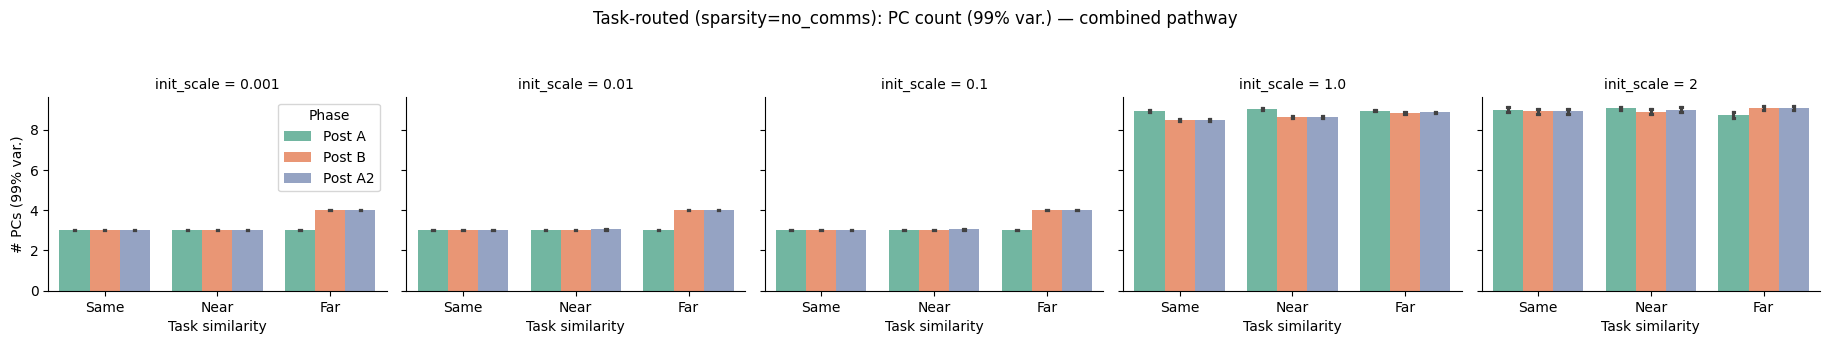

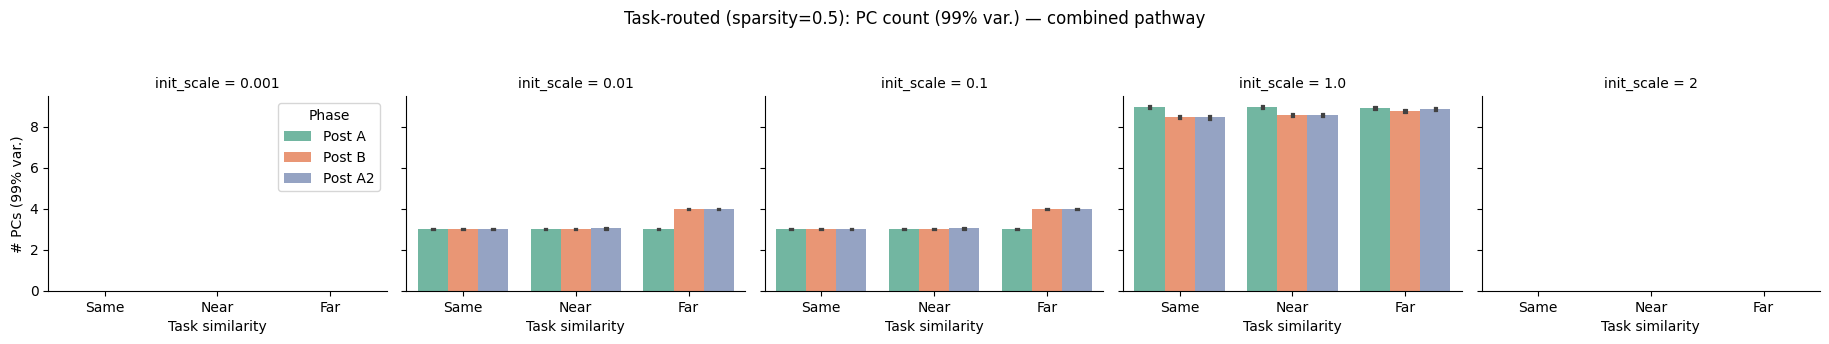

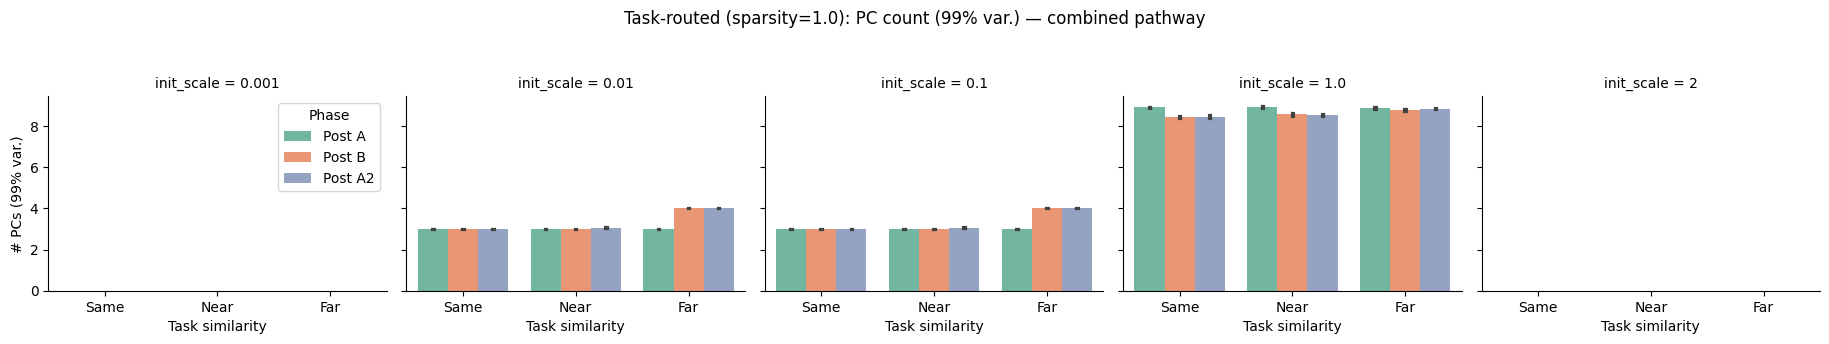

In [36]:
if not rep_task.empty:
    pc = rep_task[(rep_task["pathway"] == "combined")].copy()
    pc["init_scale"] = pc["init_scale"].astype(float)
    pc["phase"] = pd.Categorical(pc["phase"], categories=PHASE_ORDER, ordered=True)
    pc["condition"] = pd.Categorical(pc["condition"], categories=SIMILARITY_ORDER, ordered=True)

    phase_labels = {"post_A": "Post A", "post_B": "Post B", "post_A2": "Post A2"}
    cond_labels = {"same": "Same", "near": "Near", "far": "Far"}

    for sp in PAPER_SPARSITIES:
        sub = pc[pc["sparsity_label"].astype(str) == sp].copy()
        if sub.empty or "n_pcs_99" not in sub.columns:
            continue

        sub["phase_plot"] = sub["phase"].map(phase_labels)
        sub["condition_plot"] = sub["condition"].map(cond_labels)

        g = sns.catplot(
            data=sub,
            x="condition_plot",
            y="n_pcs_99",
            hue="phase_plot",
            col="init_scale",
            col_order=init_order,
            kind="bar",
            order=["Same", "Near", "Far"],
            hue_order=["Post A", "Post B", "Post A2"],
            palette="Set2",
            height=3.2,
            aspect=1.15,
            legend_out=False,
            errorbar="se",
            capsize=0.04,
        )
        g.set_axis_labels("Task similarity", "# PCs (99% var.)")
        g.set_titles("init_scale = {col_name}")
        if g._legend is not None:
            g._legend.set_title("Phase")
        g.fig.suptitle(f"Task-routed (sparsity={sp}): PC count (99% var.) — combined pathway", y=1.06)
        plt.tight_layout()
        plt.show()


## Figure 4 (draft): Curated 2D PCA geometry snapshots (task-routed)

Goal: show qualitative geometry differences without exploding the grid.

Default: use `post_A2`, pathway `combined`, and show a small curated subset.

Draft subset:
- sparsity = `0.5`
- init_scale ∈ {0.001, 0.01, 0.1, 1.0, 2}
- three panels per figure: similarity (same/near/far)

(You can add `no_comms` and `full` as supplemental versions.)


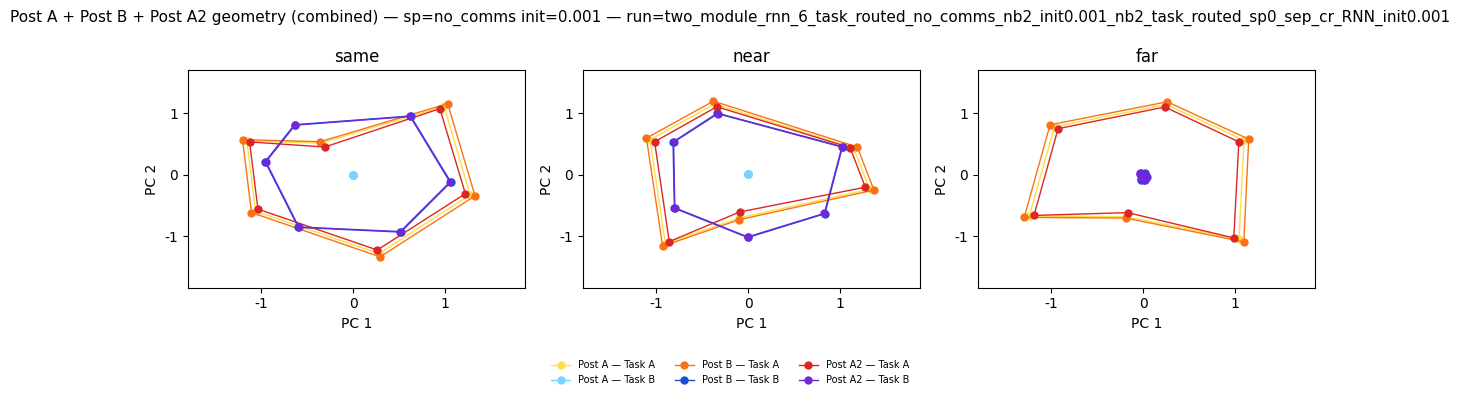

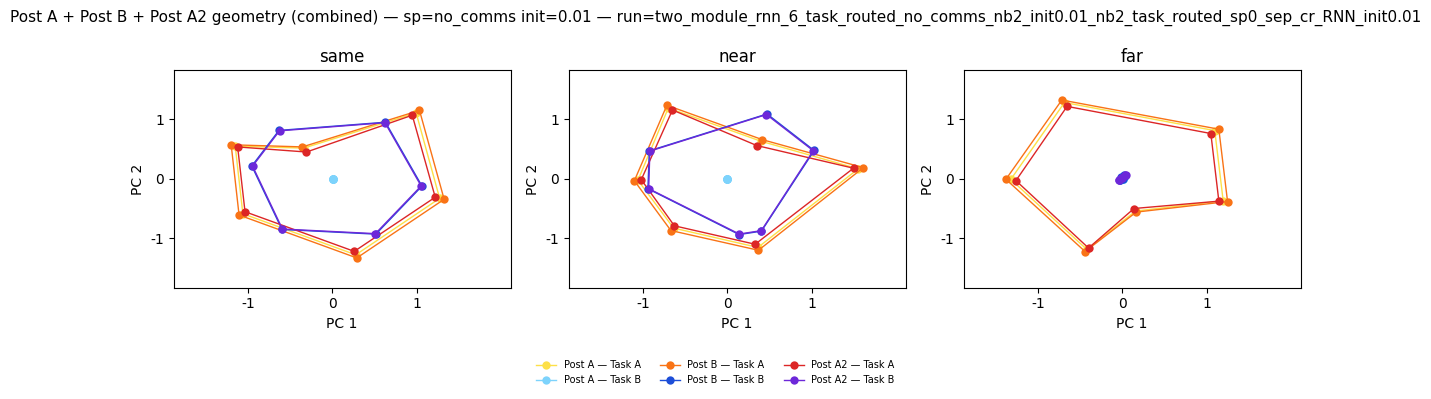

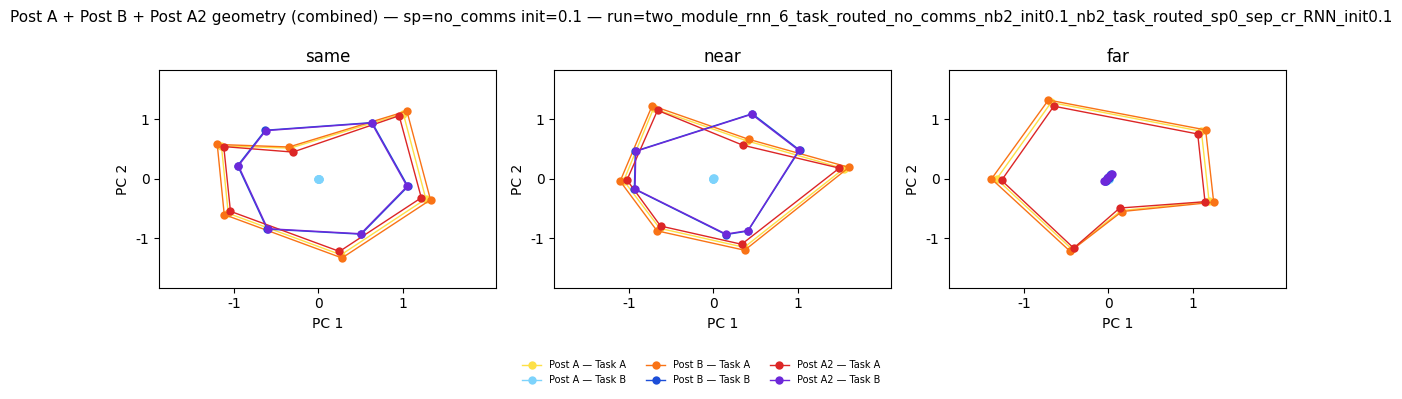

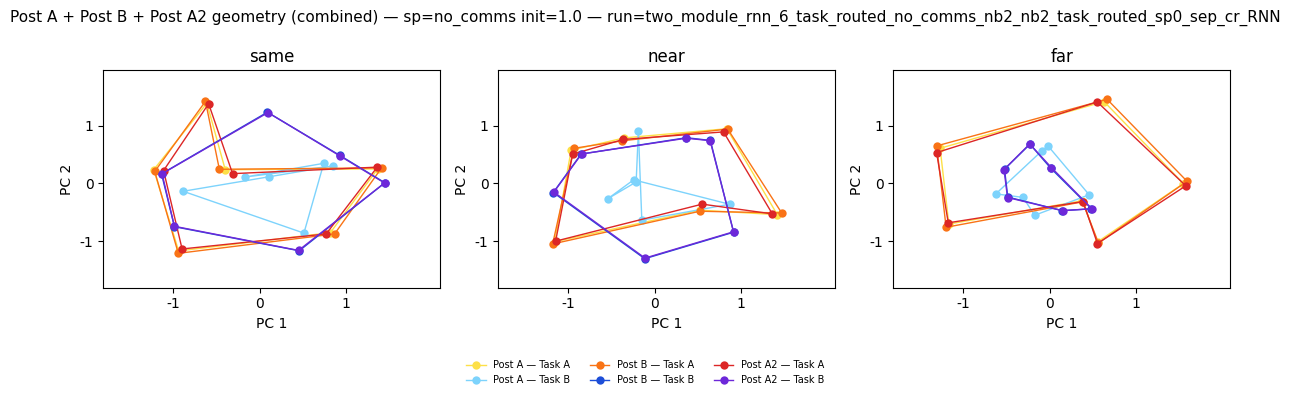

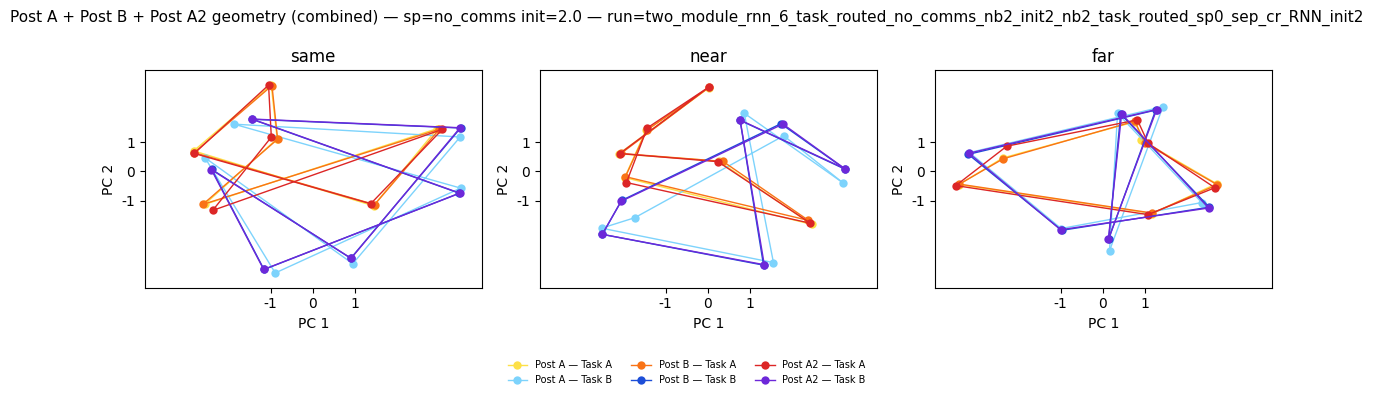

No candidate run found for 0.5 0.001


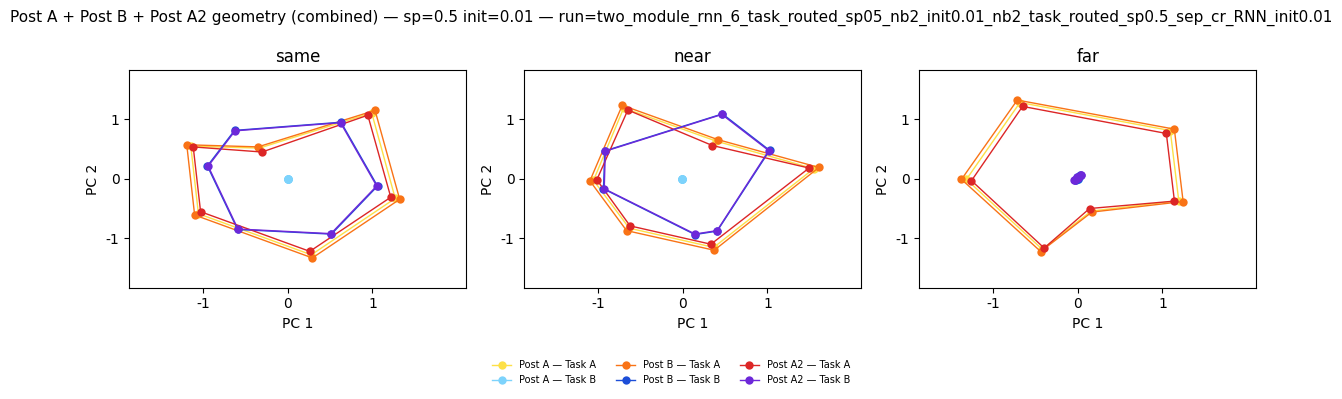

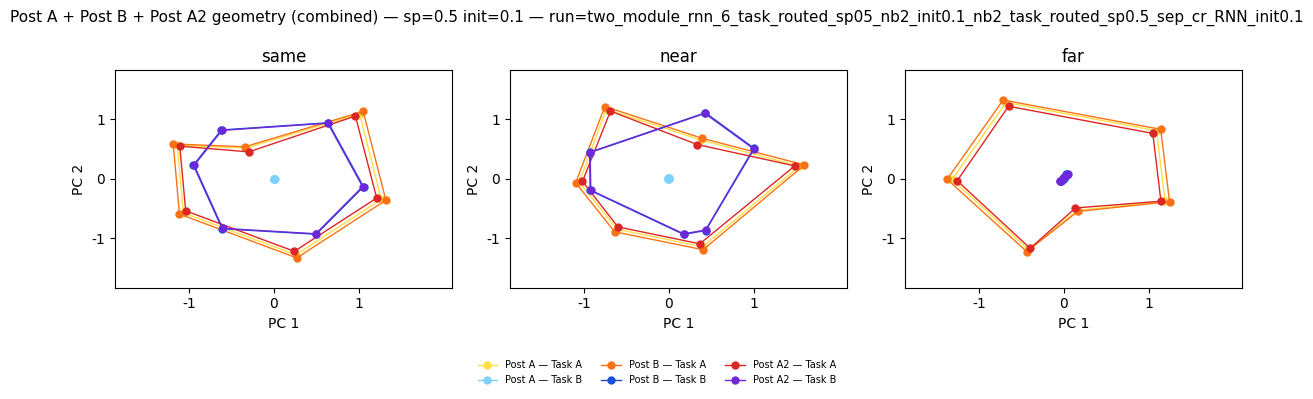

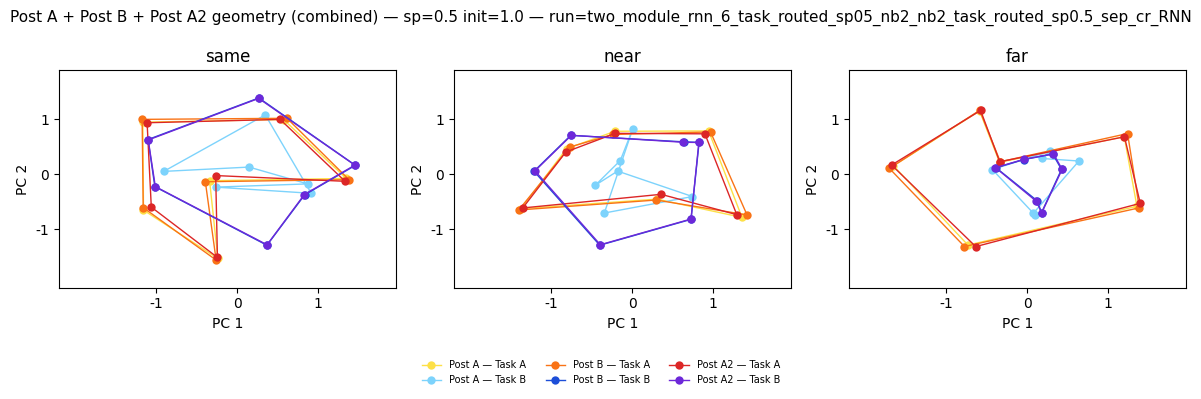

No candidate run found for 0.5 2.0
No candidate run found for 1.0 0.001


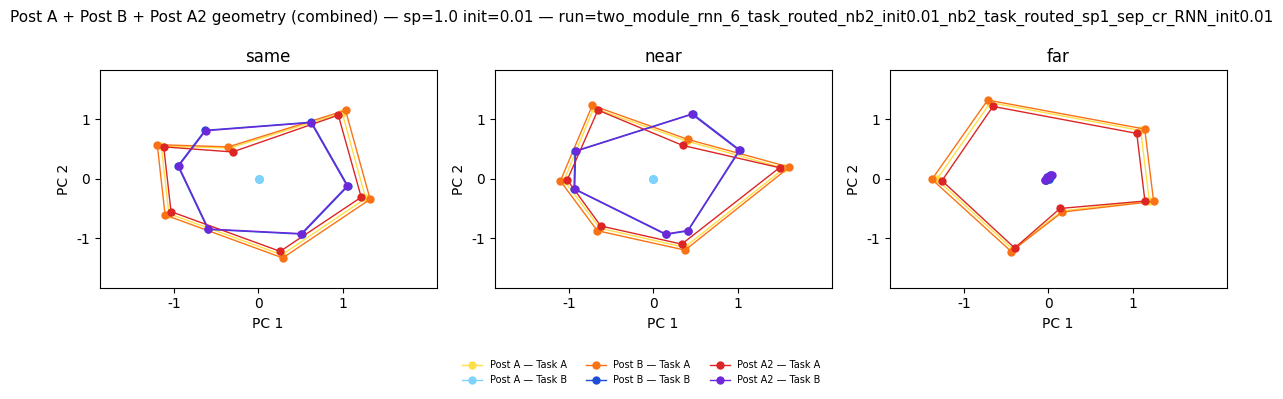

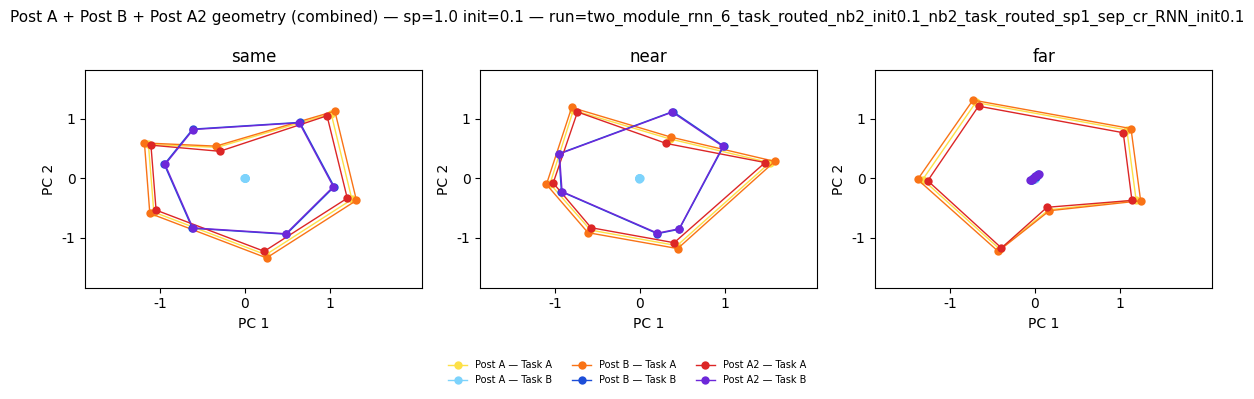

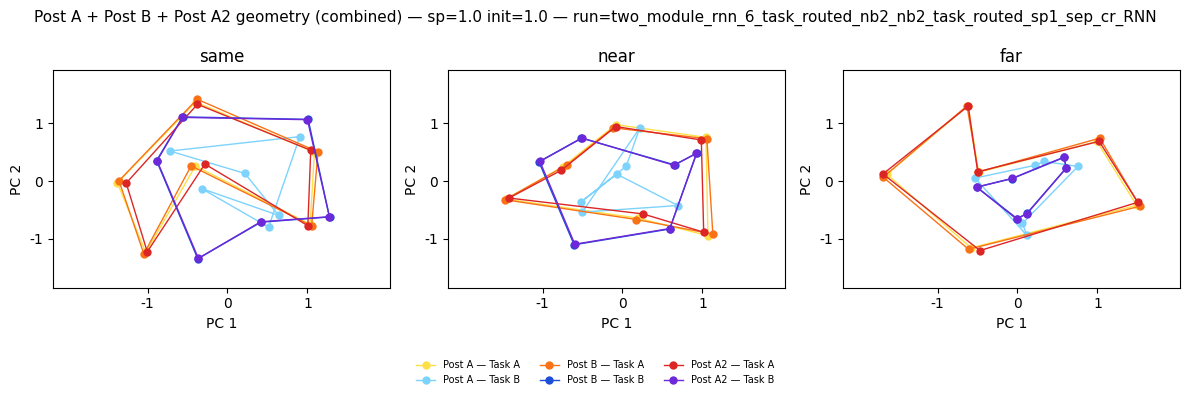

No candidate run found for 1.0 2.0


In [37]:
def plot_geometry_snapshot(all_ann_data: dict, target_sp: str, target_init: float, n_stim_plot: int = 12):
    # pick the first run that matches (sp, init)
    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found for", target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Post A + Post B + Post A2 geometry (combined) — sp={target_sp} init={target_init} — run={run_id}", fontsize=11)

    all_triples = []
    for cond in SIMILARITY_ORDER:
        entries = ann_data.get(cond, [])
        if not entries:
            all_triples.append(None)
            continue
        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            all_triples.append(None)
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            all_triples.append(None)
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            all_triples.append(None)
            continue
        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X2_A, X2_B, X2_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=2)
        all_triples.append((X2_A, X2_B, X2_A2))

    flat = []
    for triple in all_triples:
        if triple is not None:
            X2_A, X2_B, X2_A2 = triple
            flat.extend([X2_A, X2_B, X2_A2])
    lims_global = get_axis_limits(np.vstack(flat)) if flat else {}

    for ax, cond, triple in zip(axes, SIMILARITY_ORDER, all_triples):
        if triple is None:
            ax.set_title(f"{cond} (no data)")
            ax.axis("off")
            continue
        X2_A, X2_B, X2_A2 = triple
        plot_split_stim_postA_postB_postA2(ax, X2_A, X2_B, X2_A2, lims_global)
        ax.set_title(cond)

    plt.tight_layout(rect=[0, 0.14, 1, 1])
    for ax in axes:
        hs, ls = ax.get_legend_handles_labels()
        if hs:
            fig.legend(
                hs, ls, loc="lower center", bbox_to_anchor=(0.5, 0.02),
                ncol=3, frameon=False, fontsize=7,
            )
            break
    plt.show()


for target_sp in ["no_comms", "0.5", "1.0"]:
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot(all_task, target_sp=target_sp, target_init=float(init_scale))


## Appendix: 3D PCA geometry snapshots (PC1, PC2, PC3)

This is an appendix-style extension of Figure 4 to preview whether adding the 3rd component clarifies separation patterns.

- x-axis: PC1
- y-axis: PC2
- z-axis: PC3

Curated subset matches Figure 4: sparsity in `{no_comms, 0.5, 1.0}` and init_scale in `{0.001, 0.01, 0.1, 1.0, 2}`.


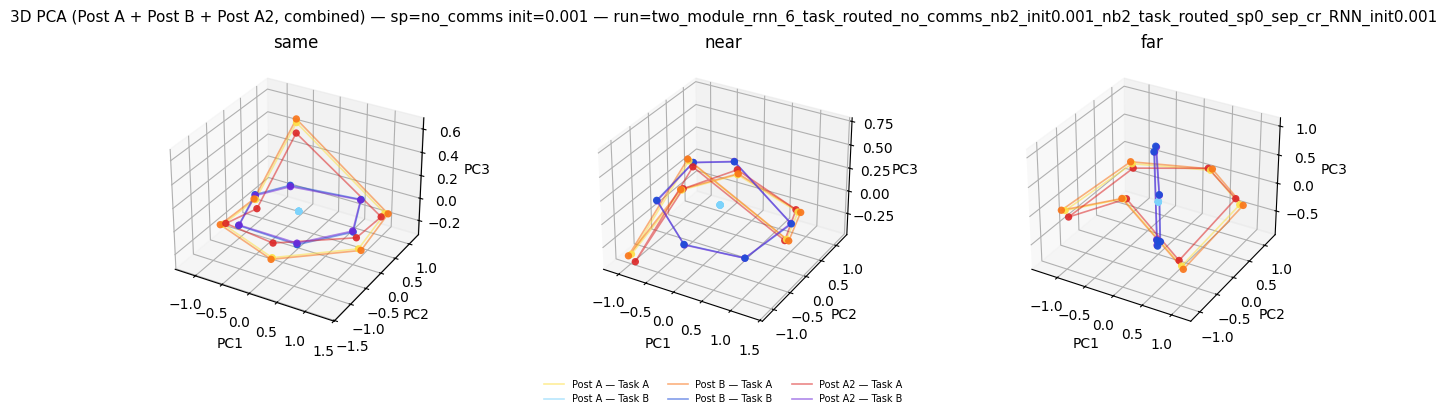

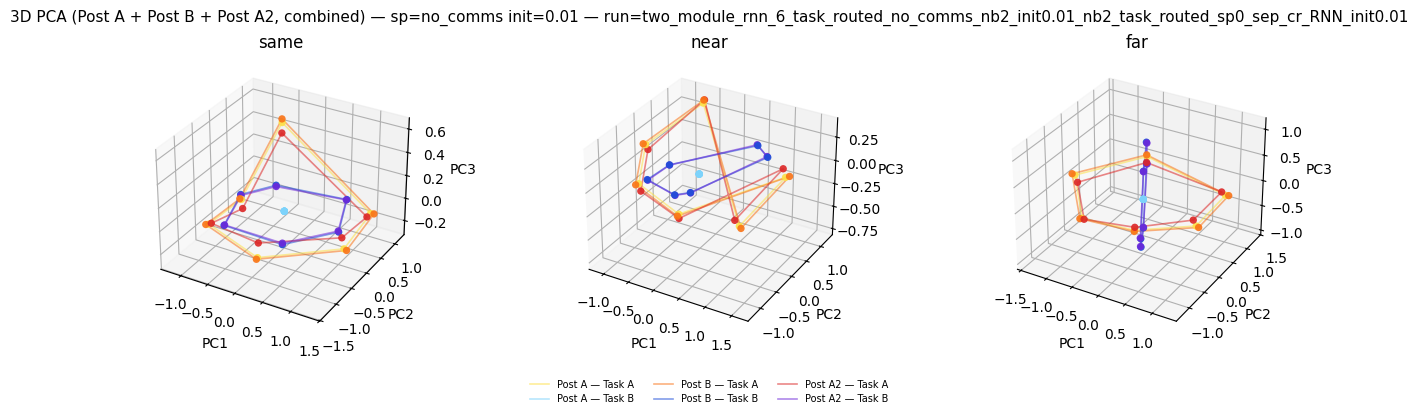

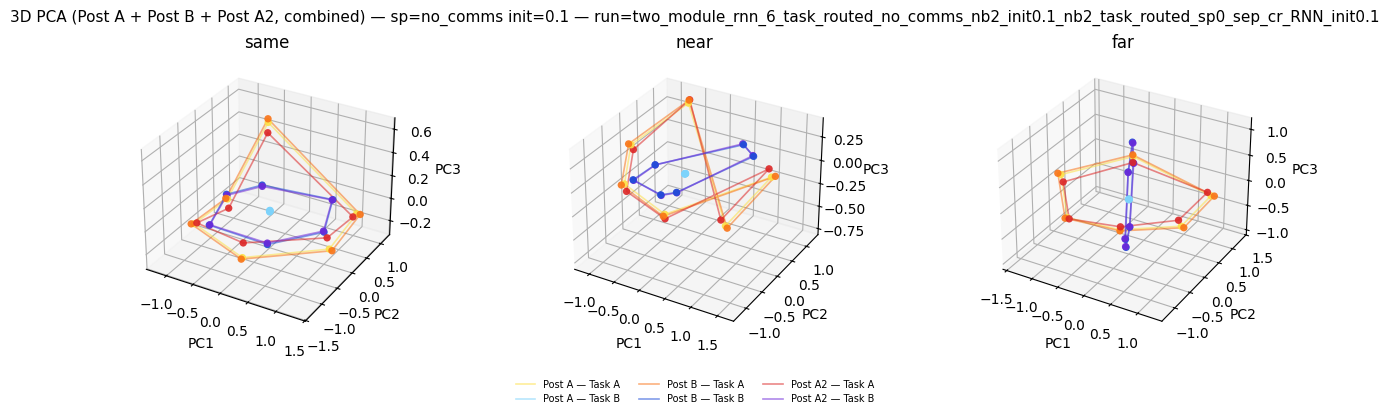

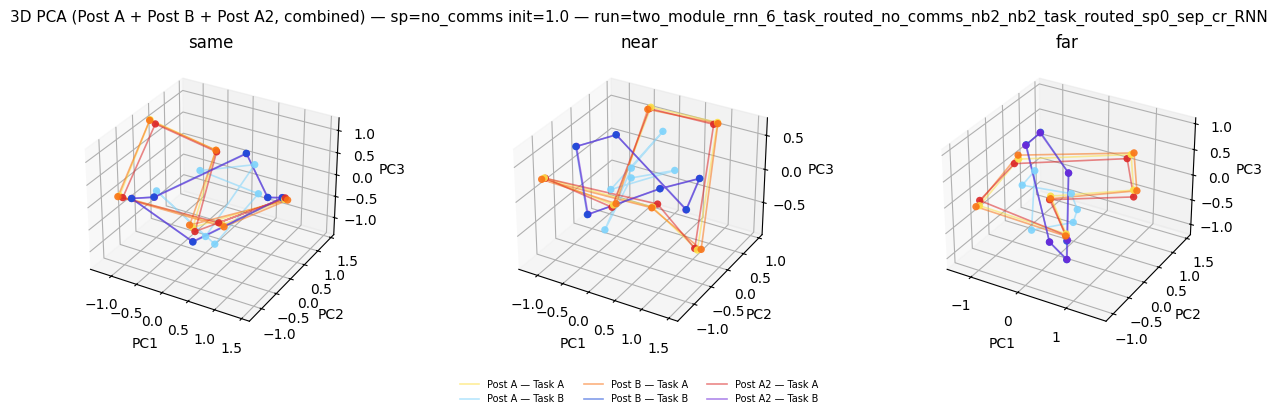

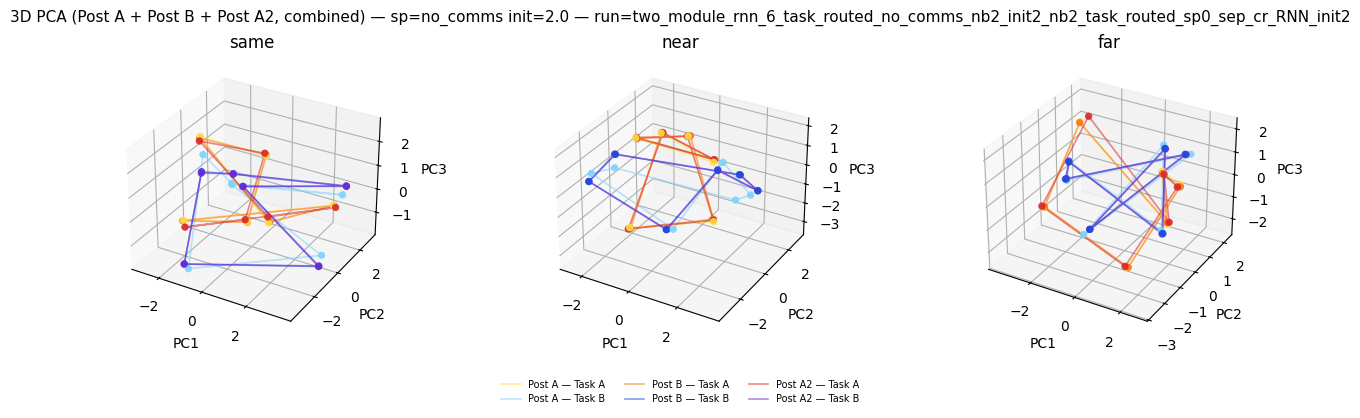

No candidate run found for 0.5 0.001


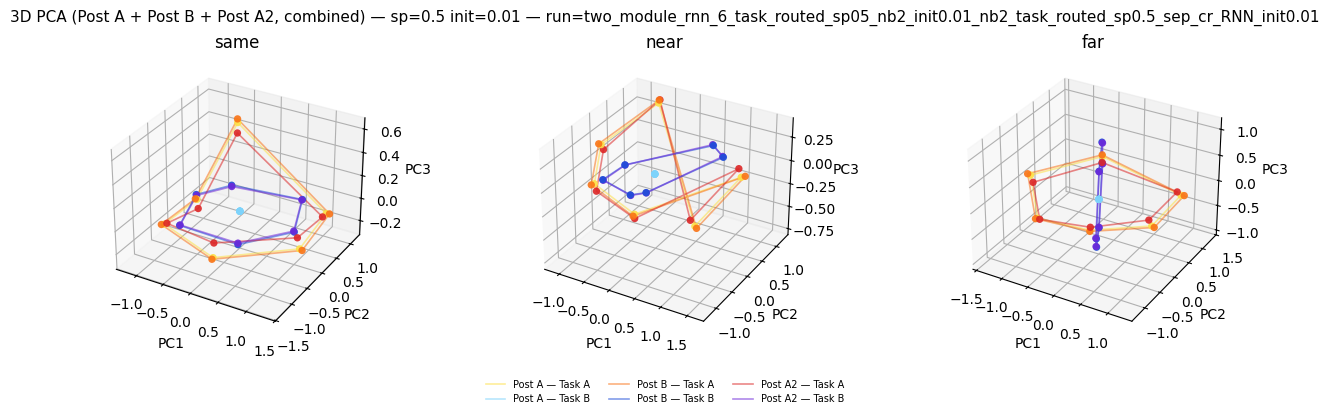

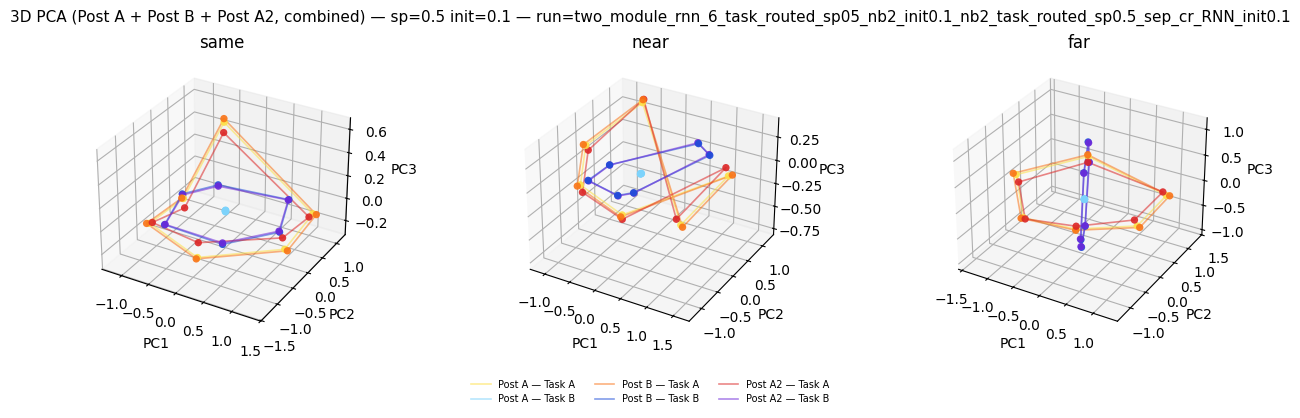

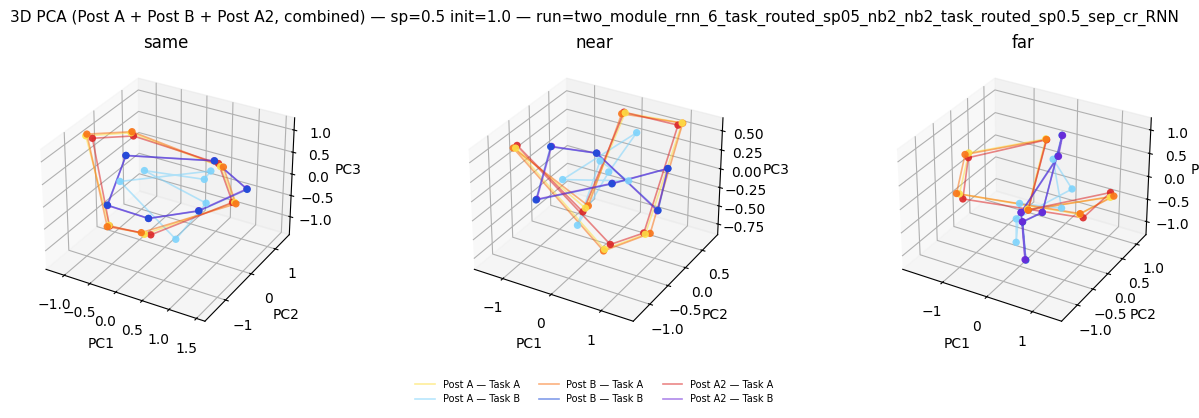

No candidate run found for 0.5 2.0
No candidate run found for 1.0 0.001


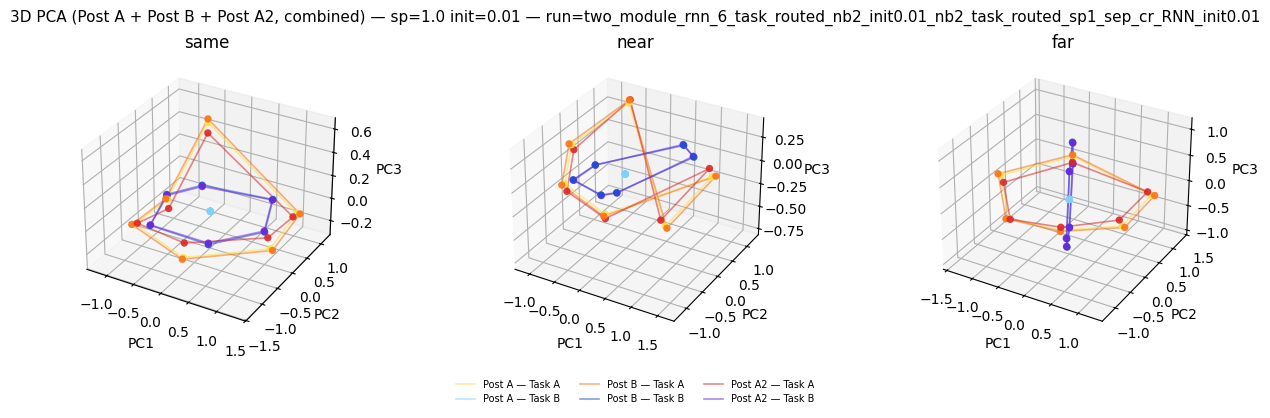

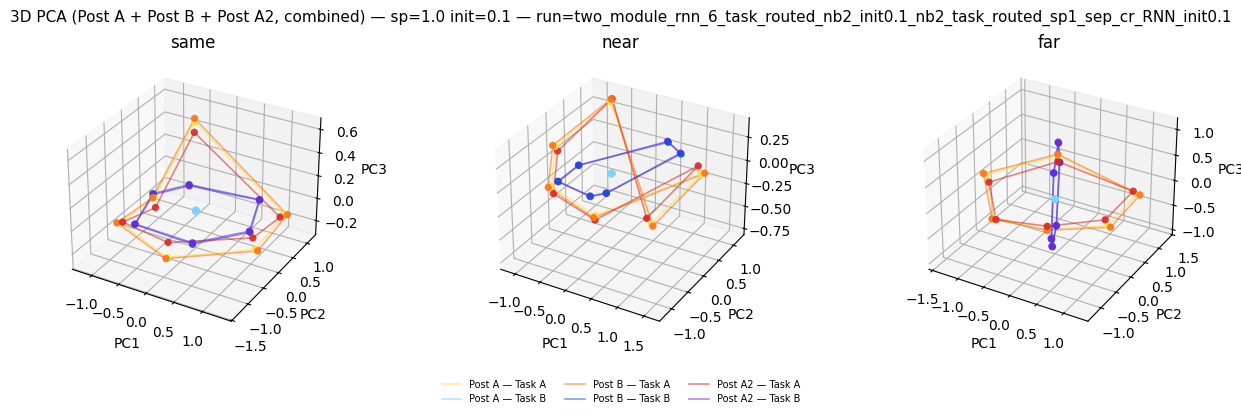

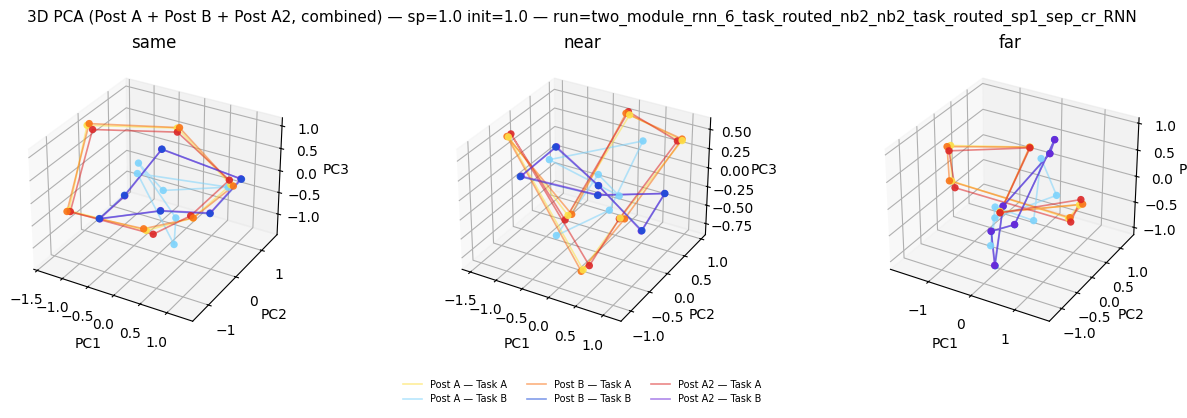

No candidate run found for 1.0 2.0


In [38]:
# 3D PCA snapshots (task-routed)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2_3d


def plot_geometry_snapshot_3d(all_ann_data: dict, target_sp: str, target_init: float, n_stim_plot: int = 12):
    candidates = [
        (rid, b) for rid, b in all_ann_data.items()
        if str(b["sparsity_label"]) == str(target_sp) and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        print("No candidate run found for", target_sp, target_init)
        return

    run_id, bundle = candidates[0]
    ann_data = bundle["data"]

    fig = plt.figure(figsize=(13, 4.2))
    fig.suptitle(f"3D PCA (Post A + Post B + Post A2, combined) — sp={target_sp} init={target_init} — run={run_id}", fontsize=11)

    legend_handles = None

    for i, cond in enumerate(SIMILARITY_ORDER, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        entries = ann_data.get(cond, [])
        if not entries:
            ax.set_title(f"{cond} (no data)")
            continue

        entry = entries[0]
        raw_A = entry.get("hiddens_post_phase_0")
        raw_B = entry.get("hiddens_post_phase_1")
        raw_A2 = entry.get("hiddens_post_phase_2")
        if raw_A is None or raw_B is None or raw_A2 is None:
            ax.set_title(f"{cond} (insufficient)")
            continue
        h_A = np.asarray(raw_A)
        h_B = np.asarray(raw_B)
        h_A2 = np.asarray(raw_A2)
        if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
            ax.set_title(f"{cond} (insufficient)")
            continue
        if h_A.shape[0] < n_stim_plot or h_B.shape[0] < n_stim_plot or h_A2.shape[0] < n_stim_plot:
            ax.set_title(f"{cond} (insufficient)")
            continue

        h_A = h_A[:n_stim_plot]
        h_B = h_B[:n_stim_plot]
        h_A2 = h_A2[:n_stim_plot]
        _, X3_A, X3_B, X3_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=3)

        with_leg = legend_handles is None
        h = plot_split_stim_postA_postB_postA2_3d(ax, X3_A, X3_B, X3_A2, labels_for_legend=with_leg)
        if legend_handles is None and h:
            legend_handles = h

        ax.set_title(cond)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")

    if legend_handles:
        fig.legend(
            legend_handles,
            [ln.get_label() for ln in legend_handles],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            fontsize=7,
        )

    plt.tight_layout(rect=[0, 0.16, 1, 1])
    plt.show()


for target_sp in ["no_comms", "0.5", "1.0"]:
    for init_scale in PAPER_INIT_SCALES:
        plot_geometry_snapshot_3d(all_task, target_sp=target_sp, target_init=float(init_scale))


## Figure 5 (draft): Shared vs task-routed ablation (matched paper grid)

Goal: treat **shared** as an ablation and compare to the **task-routed** default.

Suggested minimal view (for first draft):
- Same figure layouts as above but with a single additional facet: `routing ∈ {task_routed, shared}`.

Below we show two compact comparisons:
- Transfer/interference (`error_diff`)
- A–B principal angles

Layout: rows = sparsity, columns = init_scale, hue = similarity, and separate figures by metric.

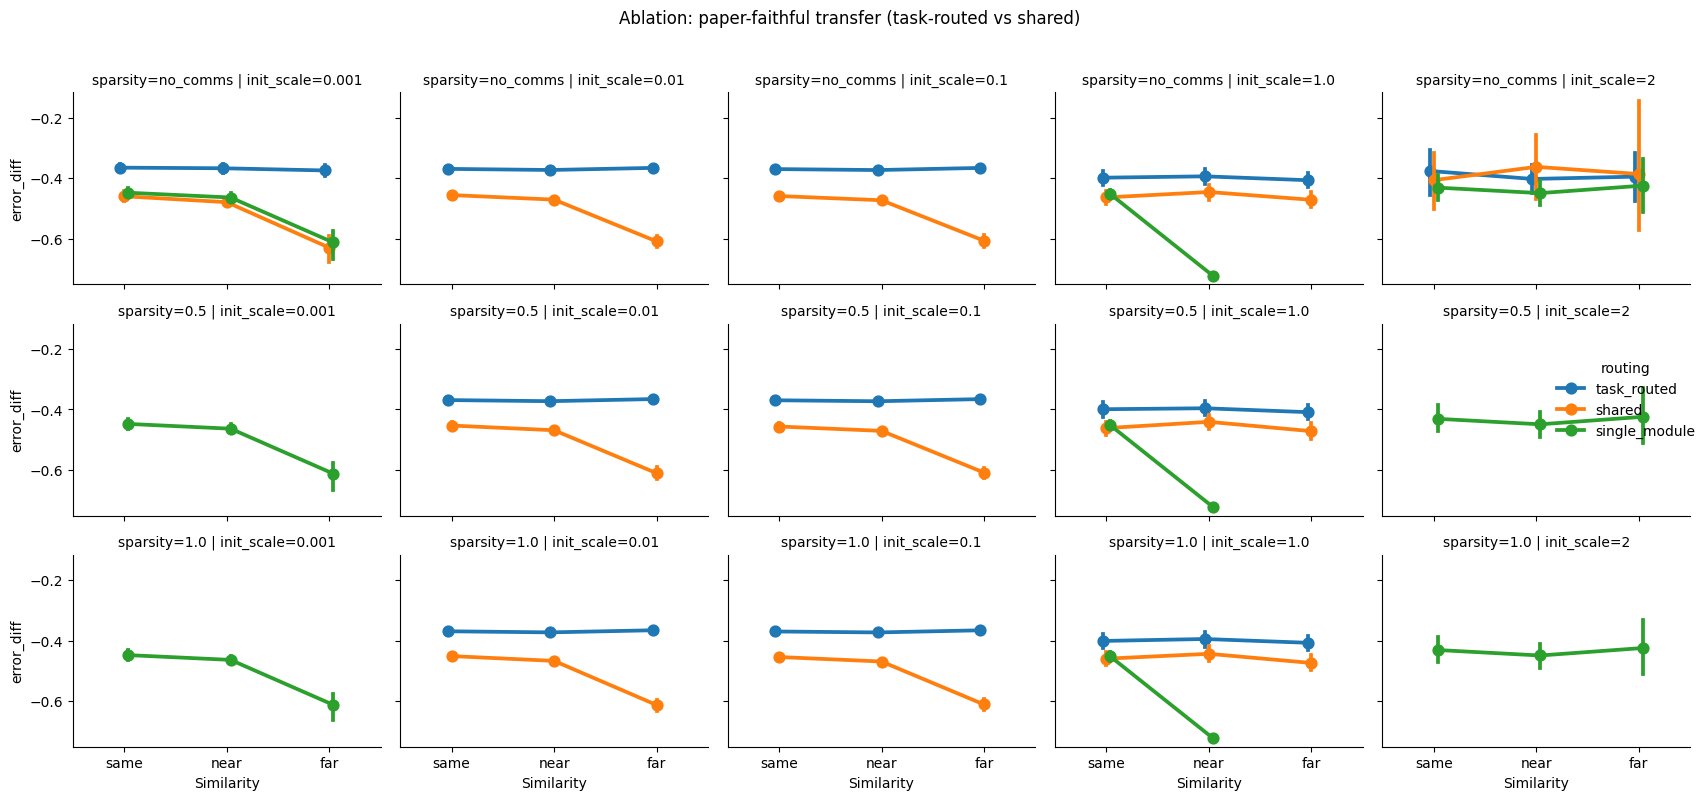

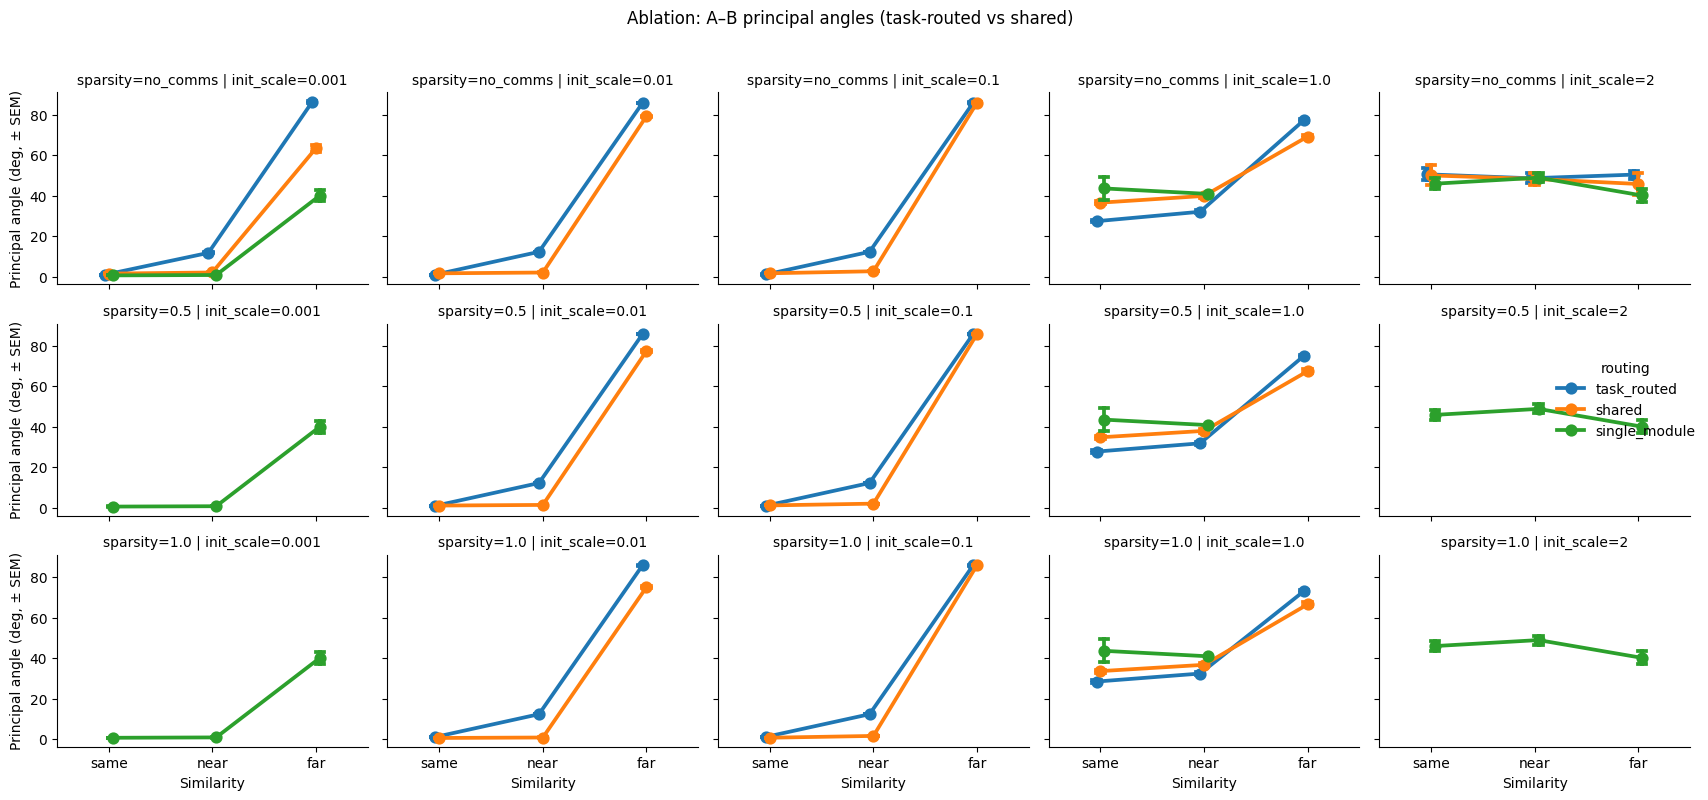

In [39]:
def add_routing_label(df: pd.DataFrame, routing: str):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["routing"] = routing
    return out

facet_sp_order = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
tr_single_x = broadcast_baseline_sparsity(transfer_single, facet_sp_order)
ang_single_x = broadcast_baseline_sparsity(angles_single, facet_sp_order)

_parts_tr = [
    add_routing_label(transfer_task, "task_routed"),
    add_routing_label(transfer_shared, "shared"),
]
if not tr_single_x.empty:
    _parts_tr.append(add_routing_label(tr_single_x, "single_module"))
tr_both = pd.concat(_parts_tr, ignore_index=True)

_parts_ang = [
    add_routing_label(angles_task, "task_routed"),
    add_routing_label(angles_shared, "shared"),
]
if not ang_single_x.empty:
    _parts_ang.append(add_routing_label(ang_single_x, "single_module"))
ang_both = pd.concat(_parts_ang, ignore_index=True)

# Transfer comparison
if not tr_both.empty:
    g = sns.catplot(
        data=tr_both,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "error_diff")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: paper-faithful transfer (task-routed vs shared)", y=1.02)
    plt.tight_layout()
    plt.show()

# Angle comparison (aggregate first)
if not ang_both.empty:
    ang_both["init_scale"] = ang_both["init_scale"].astype(float)
    g = sns.catplot(
        data=ang_both,
        x="condition",
        y="principal_angle_between",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=init_order,
        row_order=sp_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Ablation: A–B principal angles (task-routed vs shared)", y=1.02)
    plt.tight_layout()
    plt.show()


## Appendix: complementary transfer / interference views

1. **Paper-faithful Task-B transfer**: winter-trial accuracy at the **start of B** vs **end of A1**, using **k=6** blocks each (`transfer_error_diff` in `PAPER_FAITHFUL_TESTING_PROTOCOL.md`). The next cell plots this via the notebook `error_diff` series (winter slice `1::2`), matching `compute_metrics`.

2. **Retest interference (von Mises)**: primary paper metric is `1 - A_weight_A2` from mixture fits (not retest accuracy deltas). Holton-style behavioural analyses also discuss rule-mixture during A2; for **circular regression** we align with the protocol’s von Mises interference where applicable.




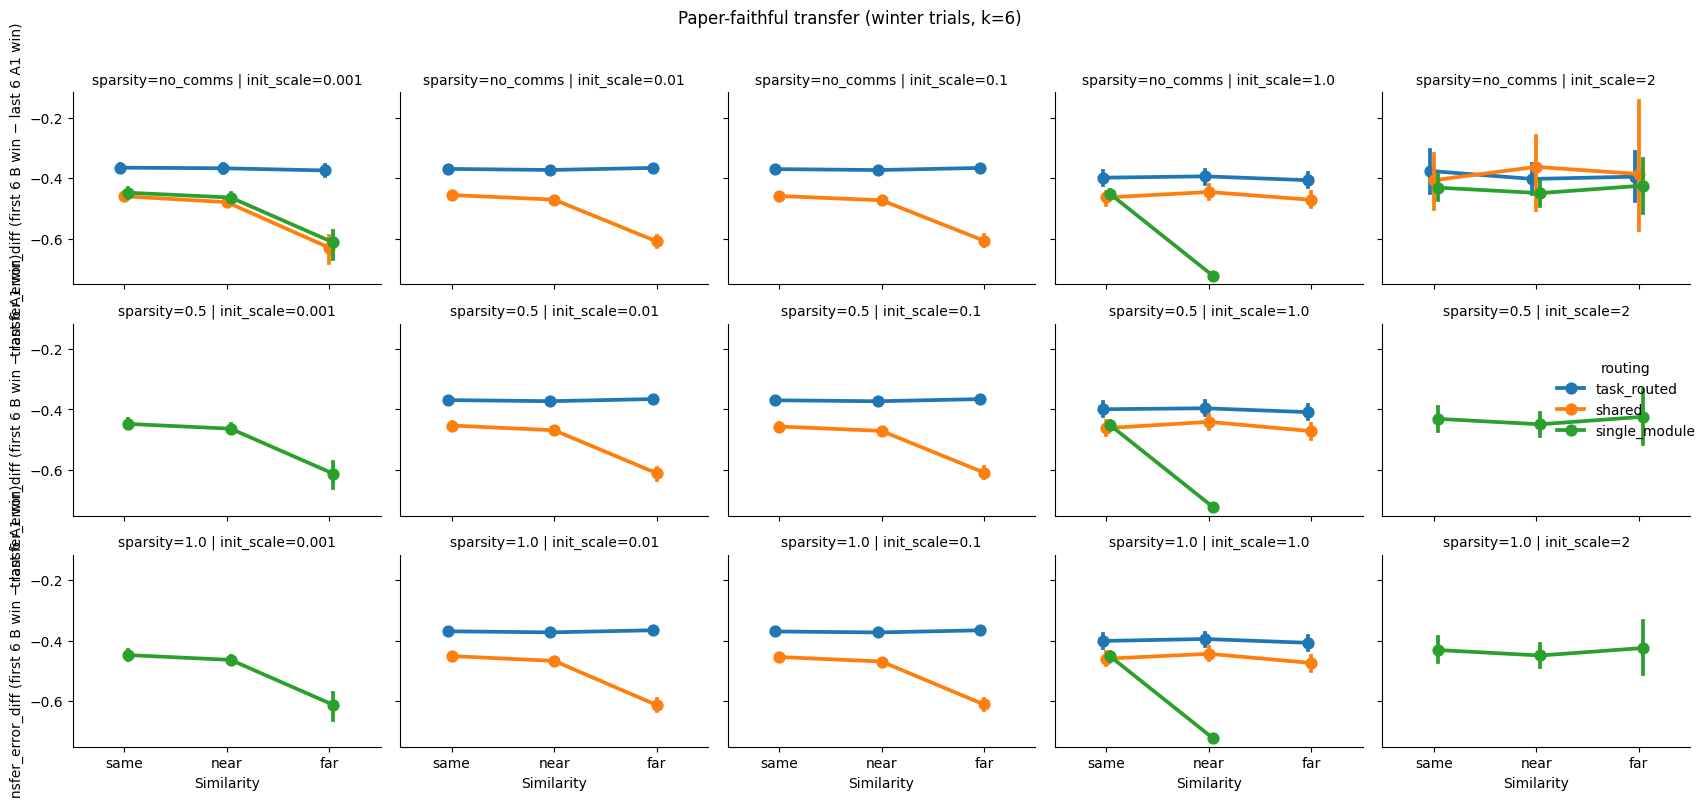

No von Mises fit CSVs available for this notebook's selected runs.


,routing,sparsity_label,init_scale,run_id,path_exists,fit_csv_exists
0,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,True,False
1,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,False,False
2,task_routed,no_comms,0.010,two_module_rnn_6_task_routed_no_comms_nb2_init...,True,False
3,task_routed,no_comms,0.010,two_module_rnn_6_task_routed_no_comms_nb2_init...,False,False
4,task_routed,no_comms,0.100,two_module_rnn_6_task_routed_no_comms_nb2_init...,True,False
...,...,...,...,...,...,...
60,single_module,1.0,0.001,single_module_rnn_12_nb2_init0.001_nb2_shared_...,True,False
61,single_module,1.0,0.010,single_module_rnn_12_nb2_init0.01_nb2_shared_s...,False,False
62,single_module,1.0,0.100,single_module_rnn_12_nb2_init0.1_nb2_shared_sp...,False,False
63,single_module,1.0,1.000,single_module_rnn_12_nb2_nb2_shared_sp1_sep_cr...,True,False


In [40]:
# A.1 Paper-faithful transfer (winter, k=6)

# Matches PAPER_FAITHFUL_TESTING_PROTOCOL.md (Transfer):
# transfer_error_diff = mean(first 6 B winter) - mean(last 6 A1 winter)
# Same as `compute_metrics` column `error_diff` (accuracy[phase, 1::2]).

facet_sp = [s for s in PAPER_SPARSITIES if s in SPARSITY_ORDER]
tr_single_f = broadcast_baseline_sparsity(transfer_single, facet_sp)
protocol_tr = pd.concat(
    [
        add_routing_label(transfer_task, "task_routed"),
        add_routing_label(transfer_shared, "shared"),
        add_routing_label(tr_single_f, "single_module"),
    ],
    ignore_index=True,
)

if not protocol_tr.empty:
    sub = protocol_tr[
        protocol_tr["init_scale"].isin(PAPER_INIT_SCALES)
        & protocol_tr["sparsity_label"].isin(PAPER_SPARSITIES)
    ].copy()

    g = sns.catplot(
        data=sub,
        x="condition",
        y="error_diff",
        hue="routing",
        col="init_scale",
        row="sparsity_label",
        col_order=PAPER_INIT_SCALES,
        row_order=PAPER_SPARSITIES,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.6,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "transfer_error_diff (first 6 B win − last 6 A1 win)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Paper-faithful transfer (winter trials, k=6)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No rows for paper-faithful transfer (error_diff).")

# A.2 Paper-faithful interference (von Mises: 1 - A_weight_A2)

# Holton-style interference uses von Mises fits at A2:
# interference = 1 - A_weight_A2
# We load per-run fit CSVs when present and ignore missing runs/fits.

def load_vonmises_interference(df_runs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if df_runs is None or df_runs.empty:
        return pd.DataFrame()

    for _, row in df_runs.iterrows():
        run_id = row["run_id"]
        fit_path = sim_folder / f"{run_id}_vonmises_fits.csv"
        if not fit_path.exists():
            continue

        fit_df = pd.read_csv(fit_path).copy()
        required = {"participant", "condition", "A_weight_A2"}
        if not required.issubset(fit_df.columns):
            continue

        fit_df = fit_df[fit_df["condition"].isin(["near", "far"])
].copy()
        if fit_df.empty:
            continue

        fit_df["run_id"] = run_id
        fit_df["init_scale"] = float(row["init_scale"])
        fit_df["sparsity_label"] = str(row["sparsity_label"])
        fit_df["interference"] = 1.0 - fit_df["A_weight_A2"].astype(float)
        rows.append(
            fit_df[["participant", "condition", "A_weight_A2", "interference", "run_id", "init_scale", "sparsity_label"]]
        )

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

vm_task = load_vonmises_interference(task_df)
vm_shared = load_vonmises_interference(shared_df)
vm_single = load_vonmises_interference(single_df)
vm_single_f = broadcast_baseline_sparsity(vm_single, facet_sp)

vm_parts = [
    add_routing_label(vm_task, "task_routed"),
    add_routing_label(vm_shared, "shared"),
]
if vm_single_f is not None and not vm_single_f.empty:
    vm_parts.append(add_routing_label(vm_single_f, "single_module"))

protocol_int = pd.concat([p for p in vm_parts if p is not None and not p.empty], ignore_index=True) if any(p is not None and not p.empty for p in vm_parts) else pd.DataFrame()

if not protocol_int.empty:
    sub = protocol_int[
        protocol_int["init_scale"].isin(PAPER_INIT_SCALES)
        & protocol_int["sparsity_label"].isin(PAPER_SPARSITIES)
        & protocol_int["condition"].isin(["near", "far"])
    ].copy()

    if not sub.empty:
        g = sns.catplot(
            data=sub,
            x="condition",
            y="interference",
            hue="routing",
            col="init_scale",
            row="sparsity_label",
            col_order=PAPER_INIT_SCALES,
            row_order=PAPER_SPARSITIES,
            kind="point",
            dodge=True,
            order=["near", "far"],
            hue_order=ROUTING_HUE_ORDER,
            palette=ROUTING_PALETTE,
            height=2.6,
            aspect=1.2,
            errorbar="se",
            capsize=0.08,
        )
        g.set_axis_labels("Similarity", "interference (1 - A_weight_A2)")
        g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
        g.fig.suptitle("Paper-faithful interference (von Mises A2 mixture)", y=1.02)
        plt.tight_layout()
        plt.show()

        display(
            sub.groupby(["routing", "sparsity_label", "init_scale", "condition"], observed=True)
            .agg(n=("participant", "nunique"), mean_interference=("interference", "mean"), sem_interference=("interference", "sem"))
            .reset_index()
            .sort_values(["routing", "sparsity_label", "init_scale", "condition"])
        )
    else:
        print("No near/far rows available for paper-faithful interference after filtering.")
else:
    missing_vm = pd.concat(
        [
            task_df.assign(routing="task_routed"),
            shared_df.assign(routing="shared"),
            single_df.assign(routing="single_module"),
        ],
        ignore_index=True,
    )
    missing_vm["fit_csv_exists"] = missing_vm["run_id"].map(lambda rid: (sim_folder / f"{rid}_vonmises_fits.csv").exists())
    print("No von Mises fit CSVs available for this notebook's selected runs.")
    display(missing_vm[["routing", "sparsity_label", "init_scale", "run_id", "path_exists", "fit_csv_exists"]])

